# Домашнее задание 2: Минимальный детектор на DETR/Deformable-DETR

### Цель

Освоить трансформерные архитектуры для объектной детекции, научиться настраивать и обучать DETR/Deformable-DETR на подмножестве COCO, анализировать loss и ошибки.

### Задание

1. Подготовить датасет: взять COCO-subset (минимум 10 классов).
2. Запустить fine-tuning DETR или Deformable-DETR на этом наборе.
3. Реализовать полный тренировочный цикл с логированием в TensorBoard.
4. Сохранить чекпойнты и trace профайлера.
5. Построить графики потерь (classification, bbox regression).
6. Провести **error analysis**: выделить ошибки классификации и локализации.

### Требования к сдаче

Репозиторий на GitHub:

* `src/` или ноутбук с кодом обучения.
* `README.md` с описанием эксперимента, гиперпараметров и основных наблюдений.
* Логи TensorBoard.
* Trace профайлера.
* Таблица метрик (mAP, mAP50).
* Визуализации предсказанных боксов + разбор ошибок.

## 1. Установка зависимостей

Если запуск через Google Colab

In [1]:
# !pip install -q kagglehub transformers timm torchmetrics pycocotools tensorboard pandas matplotlib tqdm Pillow

## 2. Импорты и конфигурация

In [2]:
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import profile, record_function, ProfilerActivity, tensorboard_trace_handler

from transformers import DetrImageProcessor, DetrForObjectDetection, AutoModelForObjectDetection
from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()

MODEL_NAME = "facebook/detr-resnet-50"
NUM_CLASSES = 10

MAX_TRAIN_IMAGES = 5000
MAX_VAL_IMAGES = 1000

EPOCHS = 5
BATCH_SIZE = 1
NUM_WORKERS = 2
LR = 1e-5
LR_BACKBONE = 1e-6
WEIGHT_DECAY = 1e-4
CLIP_MAX_NORM = 0.1

CONF_THRESHOLD_FOR_MAP = 0.01
CONF_THRESHOLD_FOR_VIS = 0.30

USE_PROFILER = True
PROFILE_WAIT_STEPS = 1
PROFILE_WARMUP_STEPS = 1
PROFILE_ACTIVE_STEPS = 3

RUN_NAME = f"detr_coco_subset_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = PROJECT_ROOT / "artifacts" / "runs" / RUN_NAME
TB_DIR = RUN_DIR / "tensorboard"
PROFILER_DIR = RUN_DIR / "profiler"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
PLOTS_DIR = RUN_DIR / "plots"
VIS_DIR = RUN_DIR / "visualizations"

for d in [TB_DIR, PROFILER_DIR, CHECKPOINT_DIR, PLOTS_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Run dir:", RUN_DIR)

Device: cuda
Run dir: /root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005


## 3. Скачивание датасета

In [3]:
import kagglehub

DATA_ROOT = Path("/root/.cache/kagglehub/datasets/abdelrahmanelgharibx/coco2017-subset/versions/1")
IMAGE_DIR = DATA_ROOT / "coco"
TRAIN_JSON = DATA_ROOT / "train2017.json"
VAL_JSON = DATA_ROOT / "val2017.json"

print("Path to dataset files:", DATA_ROOT)
print("Subfolders:", [p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
print("Files:", [p.name for p in DATA_ROOT.iterdir() if p.is_file()])

assert TRAIN_JSON.exists(), f"Не найден {TRAIN_JSON}"
assert VAL_JSON.exists(), f"Не найден {VAL_JSON}"
assert IMAGE_DIR.exists(), f"Не найдена папка с изображениями {IMAGE_DIR}"

Path to dataset files: /root/.cache/kagglehub/datasets/abdelrahmanelgharibx/coco2017-subset/versions/1
Subfolders: ['coco']
Files: ['val2017.json', 'train2017.json']


## 4. Просмотр структуры COCO JSON и выбор классов

В COCO JSON есть три ключевые части:

- `images`: список изображений и их `file_name`, `height`, `width`;
- `annotations`: bounding boxes и `category_id` для объектов;
- `categories`: словарь id классов и названий.

В этом ноутбуке выбираются `NUM_CLASSES` самых частых классов из train-разметки. Старые COCO `category_id` переиндексируются в `0..NUM_CLASSES-1`, чтобы классификационная голова DETR работала корректно.

In [4]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_coco = load_json(TRAIN_JSON)
val_coco = load_json(VAL_JSON)

print("Train images:", len(train_coco.get("images", [])))
print("Train annotations:", len(train_coco.get("annotations", [])))
print("Val images:", len(val_coco.get("images", [])))
print("Val annotations:", len(val_coco.get("annotations", [])))
print("Categories:", len(train_coco.get("categories", [])))

categories_by_old_id = {int(c["id"]): c["name"] for c in train_coco["categories"]}
ann_counter = Counter(int(a["category_id"]) for a in train_coco["annotations"] if int(a.get("iscrowd", 0)) == 0)

top_categories = ann_counter.most_common(NUM_CLASSES)
assert len(top_categories) >= 10, "В датасете найдено меньше 10 классов с аннотациями."

selected_old_ids = [old_id for old_id, _ in top_categories]
old_to_new = {old_id: new_id for new_id, old_id in enumerate(selected_old_ids)}
id2label = {new_id: categories_by_old_id[old_id] for old_id, new_id in old_to_new.items()}
label2id = {label: idx for idx, label in id2label.items()}

selected_df = pd.DataFrame([
    {
        "new_id": old_to_new[old_id],
        "old_coco_category_id": old_id,
        "class_name": categories_by_old_id[old_id],
        "train_instances": count,
    }
    for old_id, count in top_categories
]).sort_values("new_id")

selected_df.to_csv(RUN_DIR / "selected_categories.csv", index=False)
with open(RUN_DIR / "selected_categories.json", "w", encoding="utf-8") as f:
    json.dump({
        "old_to_new": old_to_new,
        "id2label": id2label,
        "selected_classes": selected_df.to_dict(orient="records"),
    }, f, ensure_ascii=False, indent=2)

selected_df

Train images: 118287
Train annotations: 860001
Val images: 5000
Val annotations: 36781
Categories: 80


,new_id,old_coco_category_id,class_name,train_instances
0,0,1,person,257253
1,1,3,car,43533
2,2,62,chair,38073
3,3,84,book,24077
4,4,44,bottle,24070
5,5,47,cup,20574
6,6,67,dining table,15695
7,7,51,bowl,14323
8,8,10,traffic light,12842
9,9,31,handbag,12342


## 5. Dataset и DataLoader для DETR

`DetrImageProcessor` сам приводит изображение и COCO-аннотации к формату, который ожидает DETR: `pixel_values`, `pixel_mask`, `class_labels`, `boxes`.

Для расчёта `mAP` отдельно сохраняются target-боксы в формате `xyxy` в исходных пикселях.

In [5]:
processor = DetrImageProcessor.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    size={
        "shortest_edge": 512,
        "longest_edge": 768,
    },
)


def sanitize_bbox_xywh(bbox, width, height):
    """Обрезает bbox по границам изображения и возвращает COCO bbox [x, y, w, h]."""
    x, y, w, h = map(float, bbox)
    x1 = max(0.0, min(x, width - 1.0))
    y1 = max(0.0, min(y, height - 1.0))
    x2 = max(0.0, min(x + w, width))
    y2 = max(0.0, min(y + h, height))
    new_w = max(0.0, x2 - x1)
    new_h = max(0.0, y2 - y1)
    if new_w <= 1.0 or new_h <= 1.0:
        return None
    return [x1, y1, new_w, new_h]


class CocoSubsetForDetr(Dataset):
    def __init__(self, annotation_file, image_dir, processor, old_to_new, max_images=None, seed=42):
        self.annotation_file = Path(annotation_file)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.old_to_new = {int(k): int(v) for k, v in old_to_new.items()}

        coco = load_json(self.annotation_file)
        self.images_by_id = {int(img["id"]): img for img in coco["images"]}
        self.annotations_by_image = defaultdict(list)

        for ann in coco["annotations"]:
            old_cat_id = int(ann["category_id"])
            image_id = int(ann["image_id"])
            if old_cat_id not in self.old_to_new:
                continue
            if int(ann.get("iscrowd", 0)) == 1:
                continue
            if image_id not in self.images_by_id:
                continue

            remapped = dict(ann)
            remapped["category_id"] = self.old_to_new[old_cat_id]
            remapped["iscrowd"] = 0
            self.annotations_by_image[image_id].append(remapped)

        image_ids = [img_id for img_id, anns in self.annotations_by_image.items() if len(anns) > 0]

        existing_files = {p.name for p in self.image_dir.glob("*.jpg")}

        image_ids = [
            img_id
            for img_id in image_ids
            if self.images_by_id[img_id]["file_name"] in existing_files
        ]

        image_ids = sorted(image_ids)

        print(
            f"{self.annotation_file.name}: оставлено {len(image_ids)} изображений "
            f"из {len(self.annotations_by_image)} изображений с нужными классами"
        )

        if max_images is not None:
            rng = random.Random(seed)
            rng.shuffle(image_ids)
            image_ids = sorted(image_ids[:max_images])

        self.image_ids = image_ids

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_info = self.images_by_id[image_id]
        img_path = self.image_dir / img_info["file_name"]
        if not img_path.exists():
            raise FileNotFoundError(f"Не найдено изображение: {img_path}")

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        clean_anns = []
        metric_boxes = []
        metric_labels = []

        for ann in self.annotations_by_image[image_id]:
            clean_bbox = sanitize_bbox_xywh(ann["bbox"], width, height)
            if clean_bbox is None:
                continue

            x, y, w, h = clean_bbox
            clean_ann = {
                "id": int(ann.get("id", len(clean_anns))),
                "image_id": int(image_id),
                "category_id": int(ann["category_id"]),
                "bbox": [x, y, w, h],
                "area": float(w * h),
                "iscrowd": 0,
            }
            clean_anns.append(clean_ann)
            metric_boxes.append([x, y, x + w, y + h])
            metric_labels.append(int(ann["category_id"]))

        target = {"image_id": int(image_id), "annotations": clean_anns}
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")

        metric_target = {
            "boxes": torch.tensor(metric_boxes, dtype=torch.float32),
            "labels": torch.tensor(metric_labels, dtype=torch.long),
            "image_id": torch.tensor([image_id], dtype=torch.long),
            "orig_size": torch.tensor([height, width], dtype=torch.long),
        }

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
            "metric_target": metric_target,
            "image_path": str(img_path),
        }


def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")

    return {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": [item["labels"] for item in batch],
        "metric_targets": [item["metric_target"] for item in batch],
        "image_paths": [item["image_path"] for item in batch],
    }


train_dataset = CocoSubsetForDetr(TRAIN_JSON, IMAGE_DIR, processor, old_to_new, max_images=MAX_TRAIN_IMAGES, seed=SEED)
val_dataset = CocoSubsetForDetr(VAL_JSON, IMAGE_DIR, processor, old_to_new, max_images=MAX_VAL_IMAGES, seed=SEED)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

assert len(train_dataset) > 0, "Train dataset пустой после фильтрации классов."
assert len(val_dataset) > 0, "Val dataset пустой после фильтрации классов."

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
)

sample_batch = next(iter(train_loader))
print("pixel_values:", sample_batch["pixel_values"].shape)
print("pixel_mask:", sample_batch["pixel_mask"].shape)
print("labels keys:", sample_batch["labels"][0].keys())

train2017.json: оставлено 68994 изображений из 84028 изображений с нужными классами
val2017.json: оставлено 2920 изображений из 3559 изображений с нужными классами
Train dataset size: 5000
Val dataset size: 1000


The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
/root/pozdeeva-maria/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


pixel_values: torch.Size([1, 3, 767, 512])
pixel_mask: torch.Size([1, 767, 512])
labels keys: dict_keys(['size', 'image_id', 'class_labels', 'boxes', 'area', 'iscrowd', 'orig_size'])


## 6. Инициализация DETR

Классификационная голова заменяется под выбранные `NUM_CLASSES`. Backbone обучается с меньшим learning rate.

In [6]:
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)

param_groups = [
    {
        "params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad],
        "lr": LR,
    },
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": LR_BACKBONE,
    },
]

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)

writer = SummaryWriter(log_dir=str(TB_DIR))
global_step = 0

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

Trainable parameters: 41281551


## 7. Функции обучения, оценки и сохранения чекпойнтов

In [7]:
def move_labels_to_device(labels, device):
    moved = []
    for target in labels:
        moved.append({k: v.to(device) if torch.is_tensor(v) else v for k, v in target.items()})
    return moved


def scalarize_loss_dict(loss_dict):
    return {k: float(v.detach().cpu().item()) for k, v in loss_dict.items() if torch.is_tensor(v) and v.numel() == 1}


def train_one_epoch(epoch, profiler=None):
    global global_step
    model.train()
    running = defaultdict(float)
    n_steps = 0

    pbar = tqdm(train_loader, desc=f"Train epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)
        labels = move_labels_to_device(batch["labels"], device)

        optimizer.zero_grad(set_to_none=True)

        with record_function("model_forward"):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss

        with record_function("model_backward"):
            loss.backward()
            if CLIP_MAX_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_MAX_NORM)
            optimizer.step()

        loss_values = scalarize_loss_dict(outputs.loss_dict)
        loss_values["loss_total"] = float(loss.detach().cpu().item())

        for name, value in loss_values.items():
            running[name] += value
            writer.add_scalar(f"train/{name}", value, global_step)

        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], global_step)
        pbar.set_postfix({"loss": f"{loss_values['loss_total']:.4f}"})

        global_step += 1
        n_steps += 1

        if profiler is not None:
            profiler.step()

    return {f"train_{k}": v / max(1, n_steps) for k, v in running.items()}


@torch.no_grad()
def evaluate(epoch):
    model.eval()
    running = defaultdict(float)
    n_steps = 0

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)

    pbar = tqdm(val_loader, desc=f"Val epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)
        labels = move_labels_to_device(batch["labels"], device)

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss_values = scalarize_loss_dict(outputs.loss_dict)
        loss_values["loss_total"] = float(outputs.loss.detach().cpu().item())

        for name, value in loss_values.items():
            running[name] += value

        target_sizes = torch.stack([t["orig_size"] for t in batch["metric_targets"]]).to(device)
        detections = processor.post_process_object_detection(
            outputs,
            threshold=CONF_THRESHOLD_FOR_MAP,
            target_sizes=target_sizes,
        )

        preds = []
        targets = []
        for det, target in zip(detections, batch["metric_targets"]):
            preds.append({
                "boxes": det["boxes"].detach().cpu(),
                "scores": det["scores"].detach().cpu(),
                "labels": det["labels"].detach().cpu().long(),
            })
            targets.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu().long(),
            })

        metric.update(preds, targets)
        n_steps += 1

    val_losses = {f"val_{k}": v / max(1, n_steps) for k, v in running.items()}
    map_result = metric.compute()

    map_value = float(map_result["map"].detach().cpu().item())
    map50_value = float(map_result["map_50"].detach().cpu().item())

    writer.add_scalar("metrics/mAP", map_value, epoch)
    writer.add_scalar("metrics/mAP50", map50_value, epoch)

    for name, value in val_losses.items():
        writer.add_scalar(name.replace("val_", "val/"), value, epoch)

    metrics = {
        **val_losses,
        "mAP": map_value,
        "mAP50": map50_value,
    }

    return metrics


def save_checkpoint(epoch, train_stats, val_stats):
    ckpt_dir = CHECKPOINT_DIR / f"epoch_{epoch:03d}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(ckpt_dir)
    processor.save_pretrained(ckpt_dir)

    torch.save({
        "epoch": epoch,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_stats": train_stats,
        "val_stats": val_stats,
        "id2label": id2label,
        "label2id": label2id,
        "old_to_new": old_to_new,
    }, ckpt_dir / "training_state.pt")

    print(f"Checkpoint saved to: {ckpt_dir}")

## 8. Запуск обучения с TensorBoard и profiler trace

Trace профайлера сохранится в папку `profiler/`. Loss и метрики сохраняются в TensorBoard.

In [8]:
history = []

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    if USE_PROFILER and epoch == 1:
        activities = [ProfilerActivity.CPU]
        if device.type == "cuda":
            activities.append(ProfilerActivity.CUDA)

        prof_schedule = torch.profiler.schedule(
            wait=PROFILE_WAIT_STEPS,
            warmup=PROFILE_WARMUP_STEPS,
            active=PROFILE_ACTIVE_STEPS,
            repeat=1,
        )

        with profile(
            activities=activities,
            schedule=prof_schedule,
            on_trace_ready=tensorboard_trace_handler(str(PROFILER_DIR)),
            record_shapes=True,
            profile_memory=True,
            with_stack=False,
        ) as prof:
            train_stats = train_one_epoch(epoch, profiler=prof)
    else:
        train_stats = train_one_epoch(epoch)

    val_stats = evaluate(epoch)
    scheduler.step()

    epoch_time_sec = time.time() - epoch_start
    row = {
        "epoch": epoch,
        "epoch_time_sec": epoch_time_sec,
        "lr": optimizer.param_groups[0]["lr"],
        **train_stats,
        **val_stats,
    }
    history.append(row)

    save_checkpoint(epoch, train_stats, val_stats)

    history_df = pd.DataFrame(history)
    history_df.to_csv(RUN_DIR / "metrics_table.csv", index=False)
    print(history_df.tail(1).T)

writer.flush()
writer.close()

history_df = pd.DataFrame(history)
history_df

Train epoch 1/5:   0%|          | 0/5000 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Val epoch 1/5:   0%|          | 0/1000 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Checkpoint saved to: /root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/checkpoints/epoch_001
                                  0
epoch                      1.000000
epoch_time_sec           581.156200
lr                         0.000009
train_loss_ce              0.756453
train_loss_bbox            0.039885
train_loss_giou            0.242130
train_cardinality_error    6.838600
train_loss_total           1.440138
val_loss_ce                0.519307
val_loss_bbox              0.048772
val_loss_giou              0.259959
val_cardinality_error      3.557000
val_loss_total             1.283086
mAP                        0.064712
mAP50                      0.116814


...

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Val epoch 5/5:   0%|          | 0/1000 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Checkpoint saved to: /root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/checkpoints/epoch_005
                                  4
epoch                      5.000000
epoch_time_sec           570.051290
lr                         0.000001
train_loss_ce              0.243439
train_loss_bbox            0.033484
train_loss_giou            0.219902
train_cardinality_error    4.448600
train_loss_total           0.850665
val_loss_ce                0.341359
val_loss_bbox              0.046402
val_loss_giou              0.255808
val_cardinality_error      4.290000
val_loss_total             1.084983
mAP                        0.207593
mAP50                      0.387844


,epoch,epoch_time_sec,lr,train_loss_ce,train_loss_bbox,train_loss_giou,train_cardinality_error,train_loss_total,val_loss_ce,val_loss_bbox,val_loss_giou,val_cardinality_error,val_loss_total,mAP,mAP50
0,1,581.156200,0.000009,0.756453,0.039885,0.242130,6.8386,1.440138,0.519307,0.048772,0.259959,3.557,1.283086,0.064712,0.116814
1,2,571.905465,0.000007,0.394908,0.039308,0.237580,3.8764,1.066606,0.414178,0.048768,0.261638,4.265,1.181296,0.162861,0.296907
2,3,615.578411,0.000004,0.304872,0.036899,0.231341,4.1664,0.952051,0.368946,0.046770,0.256195,4.410,1.115185,0.192034,0.361987
3,4,575.694818,0.000002,0.262179,0.034959,0.225165,4.4828,0.887304,0.353174,0.046305,0.258918,4.181,1.102537,0.199325,0.377935
4,5,570.051290,0.000001,0.243439,0.033484,0.219902,4.4486,0.850665,0.341359,0.046402,0.255808,4.290,1.084983,0.207593,0.387844


## 9. Графики loss

Строим графики classification loss (`loss_ce`) и bbox regression loss (`loss_bbox`). Дополнительно выводим `loss_giou` и total loss, если они есть в истории.

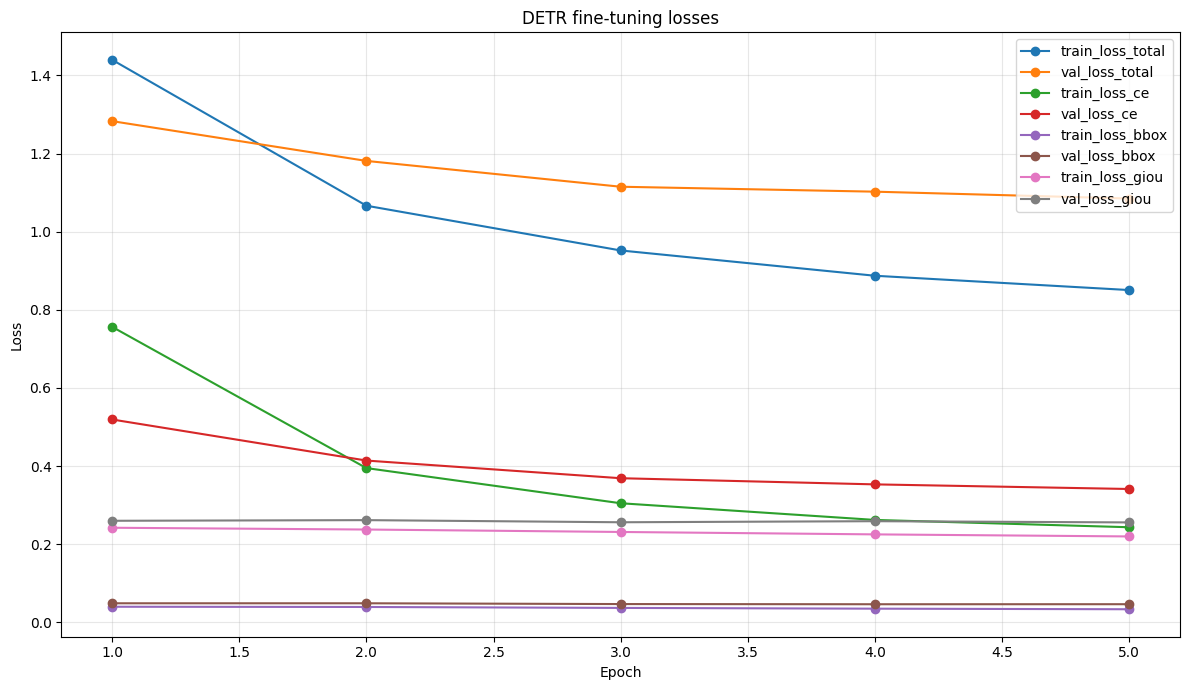

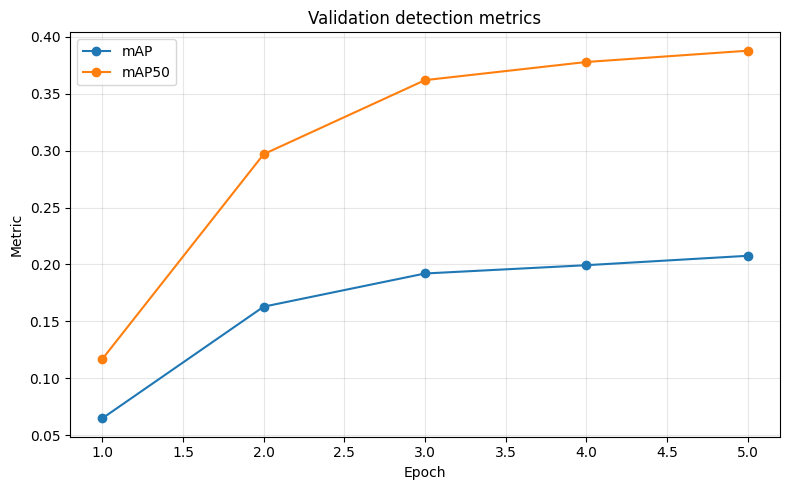

In [9]:
history_df = pd.read_csv(RUN_DIR / "metrics_table.csv")

loss_columns = [
    "train_loss_total", "val_loss_total",
    "train_loss_ce", "val_loss_ce",
    "train_loss_bbox", "val_loss_bbox",
    "train_loss_giou", "val_loss_giou",
]
loss_columns = [c for c in loss_columns if c in history_df.columns]

plt.figure(figsize=(12, 7))
for col in loss_columns:
    plt.plot(history_df["epoch"], history_df[col], marker="o", label=col)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR fine-tuning losses")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "loss_curves.png", dpi=160)
plt.show()

metric_columns = [c for c in ["mAP", "mAP50"] if c in history_df.columns]
if metric_columns:
    plt.figure(figsize=(8, 5))
    for col in metric_columns:
        plt.plot(history_df["epoch"], history_df[col], marker="o", label=col)
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title("Validation detection metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "metrics_curves.png", dpi=160)
    plt.show()

## 10. Error analysis

Логика разбора ошибок:

- `correct`: найден предсказанный бокс с IoU ≥ 0.5 и правильным классом;
- `classification_error`: IoU ≥ 0.5, но класс неверный;
- `localization_error`: класс верный, но IoU находится между 0.1 и 0.5;
- `classification_and_localization_error`: есть пересечение IoU ≥ 0.1, но и класс неверный, и локализация плохая;
- `missed_object`: для GT-объекта нет подходящего предсказания с IoU ≥ 0.1;
- `false_positive`: предсказание не соответствует ни одному GT-объекту.

In [10]:
def box_iou_xyxy(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-6)


@torch.no_grad()
def run_error_analysis(max_images=100, score_threshold=CONF_THRESHOLD_FOR_VIS, iou_correct=0.5, iou_low=0.1):
    model.eval()
    rows = []
    processed_images = 0

    for batch in tqdm(val_loader, desc="Error analysis"):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
        target_sizes = torch.stack([t["orig_size"] for t in batch["metric_targets"]]).to(device)
        detections = processor.post_process_object_detection(
            outputs,
            threshold=score_threshold,
            target_sizes=target_sizes,
        )

        for det, target, image_path in zip(detections, batch["metric_targets"], batch["image_paths"]):
            pred_boxes = det["boxes"].detach().cpu()
            pred_scores = det["scores"].detach().cpu()
            pred_labels = det["labels"].detach().cpu().long()

            gt_boxes = target["boxes"].detach().cpu()
            gt_labels = target["labels"].detach().cpu().long()
            image_id = int(target["image_id"].item())

            if len(pred_boxes) == 0:
                for gi in range(len(gt_boxes)):
                    rows.append({
                        "image_id": image_id,
                        "image_path": image_path,
                        "error_type": "missed_object",
                        "gt_label_id": int(gt_labels[gi].item()),
                        "gt_label": id2label[int(gt_labels[gi].item())],
                        "pred_label_id": None,
                        "pred_label": None,
                        "score": None,
                        "iou": 0.0,
                    })
                processed_images += 1
                continue

            ious = box_iou_xyxy(gt_boxes, pred_boxes)
            matched_pred_indices = set()

            for gi in range(len(gt_boxes)):
                best_iou, best_pi = ious[gi].max(dim=0)
                best_iou_value = float(best_iou.item())
                best_pi_value = int(best_pi.item())

                gt_label_id = int(gt_labels[gi].item())
                pred_label_id = int(pred_labels[best_pi_value].item())
                score = float(pred_scores[best_pi_value].item())

                if best_iou_value < iou_low:
                    error_type = "missed_object"
                elif best_iou_value >= iou_correct and pred_label_id == gt_label_id:
                    error_type = "correct"
                    matched_pred_indices.add(best_pi_value)
                elif best_iou_value >= iou_correct and pred_label_id != gt_label_id:
                    error_type = "classification_error"
                    matched_pred_indices.add(best_pi_value)
                elif best_iou_value < iou_correct and pred_label_id == gt_label_id:
                    error_type = "localization_error"
                    matched_pred_indices.add(best_pi_value)
                else:
                    error_type = "classification_and_localization_error"
                    matched_pred_indices.add(best_pi_value)

                rows.append({
                    "image_id": image_id,
                    "image_path": image_path,
                    "error_type": error_type,
                    "gt_label_id": gt_label_id,
                    "gt_label": id2label[gt_label_id],
                    "pred_label_id": pred_label_id,
                    "pred_label": id2label.get(pred_label_id, str(pred_label_id)),
                    "score": score,
                    "iou": best_iou_value,
                })

            for pi in range(len(pred_boxes)):
                if pi in matched_pred_indices:
                    continue
                max_iou_to_gt = float(ious[:, pi].max().item()) if len(gt_boxes) > 0 else 0.0
                if max_iou_to_gt < iou_correct:
                    pred_label_id = int(pred_labels[pi].item())
                    rows.append({
                        "image_id": image_id,
                        "image_path": image_path,
                        "error_type": "false_positive",
                        "gt_label_id": None,
                        "gt_label": None,
                        "pred_label_id": pred_label_id,
                        "pred_label": id2label.get(pred_label_id, str(pred_label_id)),
                        "score": float(pred_scores[pi].item()),
                        "iou": max_iou_to_gt,
                    })

            processed_images += 1
            if max_images is not None and processed_images >= max_images:
                error_df = pd.DataFrame(rows)
                error_df.to_csv(RUN_DIR / "error_analysis.csv", index=False)
                return error_df

    error_df = pd.DataFrame(rows)
    error_df.to_csv(RUN_DIR / "error_analysis.csv", index=False)
    return error_df


error_df = run_error_analysis(max_images=min(100, len(val_dataset)))
error_counts = error_df["error_type"].value_counts().reset_index()
error_counts.columns = ["error_type", "count"]
error_counts.to_csv(RUN_DIR / "error_counts.csv", index=False)
error_counts

Error analysis:   0%|          | 0/1000 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


,error_type,count
0,false_positive,586
1,correct,439
2,localization_error,87
3,missed_object,71
4,classification_and_localization_error,23
5,classification_error,10


## 11. График количества ошибок

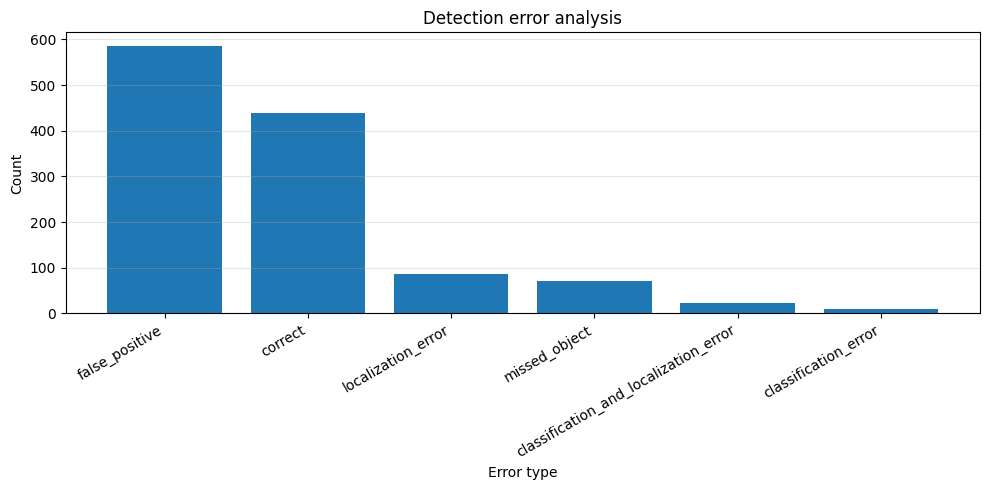

In [11]:
if not error_counts.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(error_counts["error_type"], error_counts["count"])
    plt.xticks(rotation=30, ha="right")
    plt.xlabel("Error type")
    plt.ylabel("Count")
    plt.title("Detection error analysis")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "error_counts.png", dpi=160)
    plt.show()

## 12. Визуализация предсказанных боксов

На изображениях:

- `GT`: реальные боксы;
- `PRED`: предсказанные боксы с confidence score.

In [12]:
def draw_text(draw, xy, text, fill):
    x, y = xy
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None
    draw.rectangle([x, y, x + max(80, 7 * len(text)), y + 14], fill="white")
    draw.text((x + 2, y + 1), text, fill=fill, font=font)


@torch.no_grad()
def save_prediction_visualizations(num_images=8, score_threshold=CONF_THRESHOLD_FOR_VIS):
    model.eval()
    saved = 0

    for batch in tqdm(val_loader, desc="Save visualizations"):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
        target_sizes = torch.stack([t["orig_size"] for t in batch["metric_targets"]]).to(device)
        detections = processor.post_process_object_detection(
            outputs,
            threshold=score_threshold,
            target_sizes=target_sizes,
        )

        for det, target, image_path in zip(detections, batch["metric_targets"], batch["image_paths"]):
            image = Image.open(image_path).convert("RGB")
            draw = ImageDraw.Draw(image)

            # GT boxes: green
            for box, label in zip(target["boxes"], target["labels"]):
                x1, y1, x2, y2 = [float(v) for v in box.tolist()]
                label_id = int(label.item())
                draw.rectangle([x1, y1, x2, y2], outline="green", width=3)
                draw_text(draw, (x1, max(0, y1 - 16)), f"GT: {id2label[label_id]}", fill="green")

            # Predicted boxes: red
            for box, score, label in zip(det["boxes"].cpu(), det["scores"].cpu(), det["labels"].cpu()):
                if float(score.item()) < score_threshold:
                    continue
                x1, y1, x2, y2 = [float(v) for v in box.tolist()]
                label_id = int(label.item())
                draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
                draw_text(
                    draw,
                    (x1, min(image.height - 16, y2 + 2)),
                    f"PRED: {id2label.get(label_id, label_id)} {float(score.item()):.2f}",
                    fill="red",
                )

            out_path = VIS_DIR / f"sample_{saved + 1:03d}.jpg"
            image.save(out_path, quality=95)
            saved += 1

            if saved >= num_images:
                print(f"Saved {saved} visualizations to {VIS_DIR}")
                return

    print(f"Saved {saved} visualizations to {VIS_DIR}")


save_prediction_visualizations(num_images=8)

Save visualizations:   0%|          | 0/1000 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Saved 8 visualizations to /root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/visualizations


## 13. Финальная сводка артефактов

Эту информацию можно перенести в `README.md` после финального запуска.

In [13]:
summary = {
    "run_dir": str(RUN_DIR),
    "tensorboard_dir": str(TB_DIR),
    "profiler_dir": str(PROFILER_DIR),
    "checkpoints_dir": str(CHECKPOINT_DIR),
    "plots_dir": str(PLOTS_DIR),
    "visualizations_dir": str(VIS_DIR),
    "metrics_table": str(RUN_DIR / "metrics_table.csv"),
    "error_analysis": str(RUN_DIR / "error_analysis.csv"),
    "selected_categories": str(RUN_DIR / "selected_categories.json"),
}

print(json.dumps(summary, ensure_ascii=False, indent=2))

if (RUN_DIR / "metrics_table.csv").exists():
    display(pd.read_csv(RUN_DIR / "metrics_table.csv"))

if (RUN_DIR / "error_counts.csv").exists():
    display(pd.read_csv(RUN_DIR / "error_counts.csv"))

{
  "run_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005",
  "tensorboard_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/tensorboard",
  "profiler_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/profiler",
  "checkpoints_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/checkpoints",
  "plots_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/plots",
  "visualizations_dir": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/visualizations",
  "metrics_table": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/metrics_table.csv",
  "error_analysis": "/root/pozdeeva-maria/detr_project/notebooks/artifacts/runs/detr_coco_subset_20260524_183005/error_analysis.cs

,epoch,epoch_time_sec,lr,train_loss_ce,train_loss_bbox,train_loss_giou,train_cardinality_error,train_loss_total,val_loss_ce,val_loss_bbox,val_loss_giou,val_cardinality_error,val_loss_total,mAP,mAP50
0,1,581.156200,0.000009,0.756453,0.039885,0.242130,6.8386,1.440138,0.519307,0.048772,0.259959,3.557,1.283086,0.064712,0.116814
1,2,571.905465,0.000007,0.394908,0.039308,0.237580,3.8764,1.066606,0.414178,0.048768,0.261638,4.265,1.181296,0.162861,0.296907
2,3,615.578411,0.000004,0.304872,0.036899,0.231341,4.1664,0.952051,0.368946,0.046770,0.256195,4.410,1.115185,0.192034,0.361987
3,4,575.694818,0.000002,0.262179,0.034959,0.225165,4.4828,0.887304,0.353174,0.046305,0.258918,4.181,1.102537,0.199325,0.377935
4,5,570.051290,0.000001,0.243439,0.033484,0.219902,4.4486,0.850665,0.341359,0.046402,0.255808,4.290,1.084983,0.207593,0.387844


,error_type,count
0,false_positive,586
1,correct,439
2,localization_error,87
3,missed_object,71
4,classification_and_localization_error,23
5,classification_error,10
